**GENERATOR**

In [ ]:
import numpy as np
import pandas as pd

SEED = 42

CONFIG = {
    "n_cities": 5,
    "stations_per_city": (8, 15),
    "n_days": 90,
    "freq": "h",                                  # was "H" (deprecated in pandas 2.2+)
    "pollutants": ["PM2.5", "PM10", "NO2", "O3", "CO"],

    # Calibration targets from spec §6 — used by validate()
    "targets": {
        "pm25_mean_range": (25.0, 60.0),
        "aqi_high_rate":   (0.10, 0.25),         # AQI > 100
        "missing_rate":    (0.05, 0.15),
    },
}

In [ ]:
def generate_pollutants():
    rows = [
        # name,   unit,     safe_limit, hazard_weight
        ("PM2.5", "µg/m³",  35.0,       1.5),
        ("PM10",  "µg/m³",  150.0,      1.0),
        ("NO2",   "µg/m³",  100.0,      1.2),
        ("O3",    "µg/m³",  70.0,       1.3),
        ("CO",    "mg/m³",  9.0,        0.8),
    ]
    df = pd.DataFrame(rows, columns=["name", "unit", "safe_limit", "hazard_weight"])
    df.insert(0, "pollutant_id", df.index)
    return df

In [ ]:
def generate_cities(config, rng):
    n = config["n_cities"]
    df = pd.DataFrame({
        "city_id":       np.arange(n),
        "population":    rng.integers(int(5e5), int(5e6), n),
        "urban_density": rng.uniform(3000, 15000, n),
        "coastal":       rng.binomial(1, 0.5, n),
        "avg_income":    rng.uniform(20000, 80000, n),
        # Synthetic city centers on a 10 × 10 grid (units arbitrary).
        "center_lat":    rng.uniform(0, 10, n),
        "center_lon":    rng.uniform(0, 10, n),
    })
    return df

In [ ]:
def generate_stations(cities, config, rng):
    rows = []
    station_id = 0
    for _, city in cities.iterrows():
        n_stations = rng.integers(*config["stations_per_city"])
        for _ in range(n_stations):
            rows.append({
                "station_id":        station_id,
                "city_id":           city["city_id"],
                # Cluster around city center with σ = 0.05 (units of the synthetic grid)
                "latitude":          city["center_lat"] + rng.normal(0, 0.05),
                "longitude":         city["center_lon"] + rng.normal(0, 0.05),
                "area_type":         rng.choice(
                    ["residential", "roadside", "industrial"],
                    p=[0.5, 0.3, 0.2]
                ),
                "maintenance_score": rng.uniform(0.6, 1.0),
                "install_year":      int(rng.integers(2010, 2024)),
            })
            station_id += 1
    return pd.DataFrame(rows)

In [ ]:
def generate_time_index(config):
    periods = config["n_days"] * 24
    return pd.date_range("2024-01-01", periods=periods, freq=config["freq"])

In [ ]:
def generate_weather(cities, time_index, rng):
    rows = []
    n_t = len(time_index)
    t_arr = np.arange(n_t)

    for _, city in cities.iterrows():
        # Temperature: seasonal (long period) + diurnal (24-hour) + noise
        temp = (
            28.0
            + 3.0 * np.sin(2 * np.pi * t_arr / 2160)            # seasonal-ish
            + 4.0 * np.sin(2 * np.pi * t_arr / 24 - np.pi/2)     # diurnal: cool at dawn
            + rng.normal(0, 1, n_t)
        )

        # Wind speed: lognormal, gusty
        wind_speed = rng.lognormal(mean=1.0, sigma=0.5, size=n_t)

        # Wind direction: random walk on the circle (smooth in time)
        wind_direction = np.cumsum(rng.normal(0, 0.2, n_t)) % (2 * np.pi)

        humidity = rng.uniform(0.6, 0.95, n_t)
        rainfall = rng.binomial(1, 0.3, n_t) * rng.exponential(5, n_t)

        df = pd.DataFrame({
            "city_id":        city["city_id"],
            "datetime":       time_index,
            "temperature":    temp,
            "wind_speed":     wind_speed,
            "wind_direction": wind_direction,
            "humidity":       humidity,
            "rainfall":       rainfall,
        })
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

In [ ]:
def generate_latent(stations, weather, rng):
    df = stations[["station_id", "city_id"]].merge(weather, on="city_id", how="left")
    n = len(df)

    # Diurnal traffic pattern (two-bump: morning + evening rush)
    hour    = df["datetime"].dt.hour.values
    weekday = (df["datetime"].dt.weekday < 5).values.astype(float)

    diurnal = (
        1.5 * np.exp(-((hour - 8) ** 2) / 8.0)    # morning rush
      + 1.7 * np.exp(-((hour - 18) ** 2) / 8.0)   # evening rush
      + 0.4                                        # baseline
    )
    weekly = weekday * 1.0 + (1 - weekday) * 0.65  # weekend dip

    df["traffic"]    = rng.lognormal(2.5, 0.3, n) * diurnal * weekly
    df["industrial"] = rng.lognormal(2.0, 0.4, n) * (0.7 + 0.3 * weekday)

    # Dispersion (spec §5.2): higher value = more atmospheric dilution.
    df["dispersion"] = (
        0.5 * df["wind_speed"]
      + 0.3 * df["rainfall"]
      + 0.2 / df["humidity"].clip(lower=0.1)
      + 0.5
    ).clip(lower=0.3)   # avoid pathological tiny dispersion

    return df[["station_id", "city_id", "datetime",
               "traffic", "industrial", "dispersion"]]

In [ ]:
from scipy.spatial.distance import cdist

def compute_distance_matrix(stations):
    coords = stations[["latitude", "longitude"]].values
    return cdist(coords, coords)

In [ ]:
# (C_low, C_high, AQI_low, AQI_high) per pollutant — US EPA breakpoints.
AQI_BREAKPOINTS = {
    "PM2.5": [(0.0, 12.0,   0,  50), (12.1, 35.4,  51, 100),
              (35.5, 55.4, 101, 150), (55.5, 150.4, 151, 200),
              (150.5, 250.4, 201, 300), (250.5, 500.4, 301, 500)],
    "PM10":  [(0, 54,    0,  50), (55, 154,   51, 100),
              (155, 254, 101, 150), (255, 354, 151, 200),
              (355, 424, 201, 300), (425, 604, 301, 500)],
    "NO2":   [(0, 53,    0,  50), (54, 100,   51, 100),
              (101, 360, 101, 150), (361, 649, 151, 200),
              (650, 1249, 201, 300), (1250, 2049, 301, 500)],
    "O3":    [(0, 54,    0,  50), (55, 70,    51, 100),
              (71, 85,   101, 150), (86, 105,  151, 200),
              (106, 200, 201, 300)],
    "CO":    [(0.0, 4.4, 0,   50), (4.5, 9.4,  51, 100),
              (9.5, 12.4, 101, 150), (12.5, 15.4, 151, 200),
              (15.5, 30.4, 201, 300), (30.5, 50.4, 301, 500)],
}

def compute_aqi_vectorized(values, pollutant_name):
    """Vectorized AQI for an array of concentration values of one pollutant."""
    values = np.asarray(values, dtype=float)
    aqi = np.full_like(values, np.nan, dtype=float)
    if pollutant_name not in AQI_BREAKPOINTS:
        return aqi
    for c_low, c_high, a_low, a_high in AQI_BREAKPOINTS[pollutant_name]:
        mask = (values >= c_low) & (values <= c_high) & np.isnan(aqi)
        aqi[mask] = ((a_high - a_low) / (c_high - c_low)) * (values[mask] - c_low) + a_low
    # Above the highest breakpoint cap at 500
    above = (values > AQI_BREAKPOINTS[pollutant_name][-1][1]) & np.isnan(aqi)
    aqi[above] = 500.0
    return aqi

def aqi_band(aqi):
    if pd.isna(aqi):     return None
    if aqi <= 50:        return "Good"
    if aqi <= 100:       return "Moderate"
    if aqi <= 150:       return "Unhealthy for Sensitive Groups"
    if aqi <= 200:       return "Unhealthy"
    if aqi <= 300:       return "Very Unhealthy"
    return "Hazardous"

In [ ]:
def generate_pollution(stations, weather, latent, pollutants_df,
                       distance_matrix, config, rng):
    """
    Time-stepping pollution generator implementing spec §5.1 – §5.6.

    For each timestep t:
      1. Look up emissions drivers (traffic, industrial, dispersion) per station.
      2. Compute spatial transport from the previous-step concentration field
         using the wind-aligned, distance-weighted neighborhood.
      3. For each pollutant, combine emissions + transport + AR(1) memory + noise.
      4. Save state for the next step.
    """

    pollutants = config["pollutants"]
    pol_id_map = dict(zip(pollutants_df["name"], pollutants_df["pollutant_id"]))

    # ----- Calibration constants (tune if validate() flags issues) -----
    # Emission weights — spec §6 ranges
    alpha1, alpha2, alpha3 = 10.0, 6.0, 2.0      # traffic, industrial, area_type

    # Pollutant-specific scaling — note CO is in mg/m³ (1000× smaller unit).
    # Values calibrated against AR(1) steady-state with row-normalized transport.
    gamma = {"PM2.5": 0.3, "PM10": 0.5, "NO2": 0.5, "O3": 0.0, "CO": 0.025}

    # Transport coefficients (spec §5.4 δ_p) — unchanged
    delta = {"PM2.5": 0.40, "PM10": 0.50, "NO2": 0.20, "O3": 0.15, "CO": 0.25}

    # AR(1) coefficients (spec §5.5 φ_p) — unchanged
    phi = {"PM2.5": 0.75, "PM10": 0.70, "NO2": 0.65, "O3": 0.60, "CO": 0.70}

    # Background/baseline floor — unchanged
    base_floor = {"PM2.5": 5.0, "PM10": 12.0, "NO2": 8.0, "O3": 25.0, "CO": 0.4}

    # Noise σ — unchanged
    noise_sigma = {"PM2.5": 3.0, "PM10": 5.0, "NO2": 4.0, "O3": 4.0, "CO": 0.15}

    # O3 special-case coefficients — unchanged
    o3_temp_coef = 1.2
    o3_no2_coef  = 0.4

    # Spike model — REDUCED from 0.005 to tame upper-tail AQI hits
    spike_prob = 0.003     # per (station, timestep, pollutant)

    # Distance decay exponent (spec §5.3 κ)
    kappa = 2.0

    # ----- Pre-compute timestep-invariant arrays -----
    n_pol   = len(pollutants)
    st_ids  = stations["station_id"].values
    n_st    = len(st_ids)
    st_city = stations["city_id"].values
    area_lookup = {"residential": 1.0, "roadside": 1.5, "industrial": 1.8}
    area_factor = stations["area_type"].map(area_lookup).values
    coords = stations[["latitude", "longitude"]].values

    # Bearings: bearing_ji[i, j] = angle from station j to station i
    dy = coords[:, None, 0] - coords[None, :, 0]
    dx = coords[:, None, 1] - coords[None, :, 1]
    bearing_ji = np.arctan2(dy, dx)              # shape (n_st, n_st)

    # Inverse-distance weights (1 / (1 + d^κ)); diagonal zero (no self-transport)
    inv_dist = 1.0 / (1.0 + distance_matrix ** kappa + 1e-9)
    np.fill_diagonal(inv_dist, 0.0)

    # ----- Index latent / weather by datetime for O(1) per-step lookup -----
    # Ensure keys are pandas Timestamps for consistency with groupby output
    latent_groups  = {t: g for t, g in latent.groupby("datetime")}
    weather_groups = {t: g for t, g in weather.groupby("datetime")}
    times = np.sort(weather["datetime"].unique())
    n_times = len(times)

    # AR(1) state — concentration at t-1 for each (station, pollutant)
    state = np.zeros((n_st, n_pol))

    # Pre-allocate output arrays (much faster than appending dicts)
    n_total = n_times * n_st * n_pol
    out_station_id   = np.empty(n_total, dtype=np.int64)
    out_city_id      = np.empty(n_total, dtype=np.int64)
    out_datetime     = np.empty(n_total, dtype="datetime64[ns]")
    out_pollutant_id = np.empty(n_total, dtype=np.int64)
    out_concentration = np.empty(n_total, dtype=np.float64)
    write_idx = 0

    for t in times:
        # Convert numpy.datetime64 to pandas.Timestamp for dictionary lookup
        timestamp_t = pd.Timestamp(t)

        # Per-station drivers, ordered to match st_ids
        lat_t = latent_groups[timestamp_t].set_index("station_id").reindex(st_ids)
        traffic       = lat_t["traffic"].values
        industrial    = lat_t["industrial"].values
        dispersion_st = lat_t["dispersion"].values

        # Per-city weather → broadcast to per-station
        wth_t = weather_groups[timestamp_t].set_index("city_id")
        wind_dir_per_city = wth_t["wind_direction"].to_dict()
        temp_per_city     = wth_t["temperature"].to_dict()
        wind_dir_st = np.array([wind_dir_per_city[c] for c in st_city])
        temp_st     = np.array([temp_per_city[c]     for c in st_city])

        # Wind-alignment matrix: how well does wind at source j point toward i?
        # alignment[i, j] = max(0, cos(wind_dir_at_j - bearing_j_to_i))
        wind_at_j = wind_dir_st[None, :]                      # broadcast over rows i
        alignment = np.maximum(0.0, np.cos(wind_at_j - bearing_ji))
        np.fill_diagonal(alignment, 0.0)

        # Combined transport weight matrix — row-normalized so T(i) is a weighted
        # AVERAGE of neighbor concentrations, not an unbounded sum. This keeps the
        # AR(1) feedback loop bounded for any choice of delta_p.
        weight = alignment * inv_dist                         # (n_st, n_st)
        row_sums = weight.sum(axis=1, keepdims=True)
        weight = np.divide(weight, row_sums,
                          out=np.zeros_like(weight),
                          where=row_sums > 1e-9)

        # Shared base emissions (spec §5.1)
        E_base = alpha1 * traffic + alpha2 * industrial + alpha3 * area_factor

        new_state = np.empty_like(state)

        for p_idx, pol in enumerate(pollutants):
            # Pollutant-specific emission scaling
            if pol in ("NO2", "CO"):
                E_pol = 0.7 * E_base + 0.3 * (traffic * 5.0)         # traffic-dominant
            elif pol in ("PM2.5", "PM10"):
                E_pol = 0.5 * E_base + 0.5 * (industrial * 3.0)      # industrial-dominant
            else:                                                    # O3 — handled specially
                E_pol = 0.3 * E_base

            # Heavy-tailed spike events (spec §7)
            spikes = rng.random(n_st) < spike_prob
            E_pol = np.where(
                spikes,
                E_pol * (1.0 + rng.lognormal(1.5, 0.5, n_st)),
                E_pol,
            )

            # Spatial transport from previous-step state
            T = weight @ state[:, p_idx]                             # (n_st,)

            # Predicted instantaneous concentration Ĉ
            if pol == "O3":
                # Spec §5.6: O3 = δ₁·T − δ₂·NO2 (NO2 from THIS timestep, computed earlier)
                no2_idx  = pollutants.index("NO2")
                no2_now  = new_state[:, no2_idx]
                C_hat = (o3_temp_coef * temp_st
                         - o3_no2_coef * no2_now
                         + delta[pol] * T
                         + base_floor[pol])
            else:
                C_hat = (gamma[pol] * E_pol / dispersion_st
                         + delta[pol] * T
                         + base_floor[pol])

            # AR(1) update (spec §5.5)
            phi_p = phi[pol]
            innov = rng.normal(0, noise_sigma[pol], n_st)
            C_t = phi_p * state[:, p_idx] + (1 - phi_p) * C_hat + innov
            C_t = np.clip(C_t, 0.0, None)

            new_state[:, p_idx] = C_t

            # Write block to output arrays
            slc = slice(write_idx, write_idx + n_st)
            out_station_id[slc]    = st_ids
            out_city_id[slc]       = st_city
            out_datetime[slc]      = t
            out_pollutant_id[slc]  = pol_id_map[pol]
            out_concentration[slc] = C_t
            write_idx += n_st

        state = new_state

    df = pd.DataFrame({
        "station_id":    out_station_id,
        "city_id":       out_city_id,
        "datetime":      out_datetime,
        "pollutant_id":  out_pollutant_id,
        "concentration": out_concentration,
    })
    df.insert(0, "reading_id", df.index)
    return df

In [ ]:
def apply_measurement(readings, stations, weather, rng):
    """
    Spec §5.7 + §5.8 + sensor drift.
      - concentration  : ground-truth (kept as latent for analysis)
      - reported_value : noisy observed value, NaN when sensor offline
      - sensor_status  : "OK" / "drift" / "offline"
    """
    df = readings.merge(
        stations[["station_id", "maintenance_score", "install_year"]],
        on="station_id",
    ).merge(
        weather[["city_id", "datetime", "rainfall"]],
        on=["city_id", "datetime"],
    )

    n = len(df)

    # Measurement noise (spec §5.7)
    noise = rng.normal(0, 2.0, n)

    # Sensor calibration drift: grows with age and time-since-min-datetime
    age_years = 2024 - df["install_year"].values
    t_min = df["datetime"].min()
    days_since_min = (df["datetime"] - t_min).dt.total_seconds().values / 86400.0
    drift = 0.02 * age_years * (days_since_min / 30.0)        # μg/m³ per month per year of age

    # Logistic missingness (spec §5.8): P = σ(-3 + 3(1 - quality) + weather_shock)
    sensor_quality = df["maintenance_score"].values
    weather_shock = (df["rainfall"].values > 10.0).astype(float) * 1.5
    logit  = -3.0 + 3.0 * (1.0 - sensor_quality) + weather_shock     # was -2.0
    p_miss = 1.0 / (1.0 + np.exp(-logit))
    offline = rng.random(n) < p_miss

    # Sensor status: most rows OK, some drift, some offline
    drift_flag = (rng.random(n) < 0.05) & (~offline)
    status = np.where(offline, "offline", np.where(drift_flag, "drift", "OK"))

    df["reported_value"] = (df["concentration"] + noise + drift).round(2)
    df.loc[offline, "reported_value"] = np.nan
    df["sensor_status"] = status

    # Drop join helpers
    return df.drop(columns=["maintenance_score", "install_year", "rainfall"])

In [ ]:
def generate_alerts(readings, pollutants_df, rng):
    """Generate alert rows per spec §2.6 + §5.10."""
    df = readings.copy()

    # Map pollutant_id -> name once for AQI lookup
    name_map = pollutants_df.set_index("pollutant_id")["name"].to_dict()
    df["_pol_name"] = df["pollutant_id"].map(name_map)

    # Vectorized AQI per pollutant
    df["aqi"] = np.nan
    for pol in df["_pol_name"].dropna().unique():
        mask = df["_pol_name"] == pol
        df.loc[mask, "aqi"] = compute_aqi_vectorized(
            df.loc[mask, "reported_value"].values, pol
        )

    # Filter to alert-worthy rows
    high = df[df["aqi"] > 100].copy()

    # Per (station, datetime), keep the worst pollutant
    high = (high
            .sort_values("aqi", ascending=False)
            .drop_duplicates(subset=["station_id", "datetime"], keep="first"))

    high["alert_level"]   = high["aqi"].apply(aqi_band)
    high["delay_minutes"] = rng.poisson(15, len(high))     # avg ~15 min reporting delay

    high = high.reset_index(drop=True)
    high["alert_id"] = high.index

    return high[["alert_id", "station_id", "datetime",
                 "pollutant_id", "alert_level", "aqi", "delay_minutes"]]

In [ ]:
def validate(readings, alerts, pollutants_df, config):
    """Print and assert calibration targets from spec §6."""
    targets = config["targets"]
    name_map = pollutants_df.set_index("pollutant_id")["name"].to_dict()

    # PM2.5 mean
    pm25_id = pollutants_df.loc[pollutants_df["name"] == "PM2.5", "pollutant_id"].iloc[0]
    pm25_vals = readings.loc[readings["pollutant_id"] == pm25_id, "reported_value"].dropna()
    pm25_mean = pm25_vals.mean()

    # AQI > 100 share — denominator is unique (station, datetime) reading-times
    n_obs_times = readings.drop_duplicates(["station_id", "datetime"]).shape[0]
    aqi_high_rate = len(alerts) / n_obs_times if n_obs_times else 0.0

    # Missing rate
    miss_rate = readings["reported_value"].isna().mean()

    print(f"PM2.5 mean         : {pm25_mean:6.2f}   target {targets['pm25_mean_range']}")
    print(f"AQI > 100 rate     : {aqi_high_rate:6.2%}   target {targets['aqi_high_rate']}")
    print(f"Missing rate       : {miss_rate:6.2%}   target {targets['missing_rate']}")
    print()
    print("Per-pollutant means:")
    for pid, name in name_map.items():
        v = readings.loc[readings["pollutant_id"] == pid, "reported_value"].dropna()
        print(f"  {name:6}: mean={v.mean():6.2f}  p95={v.quantile(0.95):6.2f}  max={v.max():7.2f}")

    # Soft asserts — convert to hard asserts once tuned
    issues = []
    lo, hi = targets["pm25_mean_range"]
    if not (lo <= pm25_mean <= hi):
        issues.append(f"PM2.5 mean {pm25_mean:.2f} outside [{lo}, {hi}]")
    lo, hi = targets["aqi_high_rate"]
    if not (lo <= aqi_high_rate <= hi):
        issues.append(f"AQI>100 rate {aqi_high_rate:.2%} outside [{lo:.0%}, {hi:.0%}]")
    lo, hi = targets["missing_rate"]
    if not (lo <= miss_rate <= hi):
        issues.append(f"Missing rate {miss_rate:.2%} outside [{lo:.0%}, {hi:.0%}]")

    if issues:
        print()
        print("⚠ Tuning needed:")
        for m in issues: print(" -", m)
    else:
        print()
        print("✓ All calibration targets met.")

In [ ]:
rng = np.random.default_rng(SEED)

pollutants = generate_pollutants()
cities     = generate_cities(CONFIG, rng)
stations   = generate_stations(cities, CONFIG, rng)
time_index = generate_time_index(CONFIG)
weather    = generate_weather(cities, time_index, rng)
latent     = generate_latent(stations, weather, rng)

distance_matrix = compute_distance_matrix(stations)

readings = generate_pollution(
    stations, weather, latent, pollutants, distance_matrix, CONFIG, rng,
)
readings = apply_measurement(readings, stations, weather, rng)
alerts   = generate_alerts(readings, pollutants, rng)

validate(readings, alerts, pollutants, CONFIG)

print(f"\nGenerated {len(readings):,} readings  |  {len(alerts):,} alerts")

PM2.5 mean         :  29.26   target (25.0, 60.0)
AQI > 100 rate     : 17.27%   target (0.1, 0.25)
Missing rate       :  9.82%   target (0.05, 0.15)

Per-pollutant means:
  PM2.5 : mean= 29.26  p95= 41.21  max= 168.56
  PM10  : mean= 65.53  p95= 86.40  max= 365.79
  NO2   : mean= 47.64  p95= 73.47  max= 360.09
  O3    : mean= 46.71  p95= 60.05  max=  79.78
  CO    : mean=  2.75  p95=  6.24  max=  31.28

✓ All calibration targets met.

Generated 680,400 readings  |  23,497 alerts


In [ ]:
def load_client_data(path, column_map=None, datetime_format=None):
    """
    Load a client CSV and return a dataframe shaped like df_model.

    Parameters
    ----------
    path : str
        Path to the client's CSV file.
    column_map : dict, optional
        Maps the standard column names this pipeline expects to the
        client's actual column names. Example:
            {"station_id": "site_code", "value": "concentration_ugm3"}
        Standard names are: station_id, datetime, pollutant, value, city_id,
        area_type, temperature, wind_speed, humidity, rainfall.
    datetime_format : str, optional
        Format string for pd.to_datetime if auto-parsing fails.

    Returns
    -------
    df : pd.DataFrame
        Long-format dataframe with one row per (station, hour, pollutant).
        Columns produced: station_id, datetime, name (pollutant), city_id,
        reported_value, hour, dayofweek, is_weekend, plus any optional
        columns the client provided.

    Raises
    ------
    ValueError
        If any required column is missing after applying column_map.
    """
    df = pd.read_csv(path)

    # Apply user-provided column rename map
    if column_map:
        df = df.rename(columns=column_map)

    # Required columns — fail loudly if missing
    required = ["station_id", "datetime", "pollutant", "value"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"Required columns missing: {missing}. "
            f"Available columns in your CSV: {list(df.columns)}. "
            f"Use the column_map argument to remap them, e.g. "
            f"load_client_data(path, column_map={{'value': 'concentration'}})"
        )

    # Coerce datetime
    if datetime_format:
        df["datetime"] = pd.to_datetime(df["datetime"], format=datetime_format)
    else:
        df["datetime"] = pd.to_datetime(df["datetime"])

    # Optional columns: warn but don't fail
    optional = ["city_id", "area_type", "temperature", "wind_speed",
                "humidity", "rainfall", "maintenance_score"]
    absent = [c for c in optional if c not in df.columns]
    if absent:
        print(f"Note — optional columns not provided: {absent}")
        print("  EDA / modeling steps that need these will be skipped or degraded.")

    # Default city_id when single-city data
    if "city_id" not in df.columns:
        df["city_id"] = 0
        print("  city_id defaulted to 0 (single-city assumption).")

    # Derived time features used by EDA + modeling
    df["hour"]       = df["datetime"].dt.hour
    df["dayofweek"]  = df["datetime"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # Rename to internal names used by downstream cells
    df = df.rename(columns={"value": "reported_value", "pollutant": "name"})

    # Normalize pollutant names to the canonical set (handled in cell 16)
    df["name"] = df["name"].apply(normalize_pollutant_name)

    print(f"\nLoaded {len(df):,} rows.")
    return df


def check_schema(df):
    """
    Print a one-page schema report for a loaded dataframe.

    Useful for the client to run immediately after load_client_data() to
    confirm their data was parsed correctly. Returns the same df unchanged
    so it can be chained.
    """
    print("=" * 60)
    print("SCHEMA REPORT")
    print("=" * 60)
    print(f"Rows                : {len(df):,}")
    print(f"Time range          : {df['datetime'].min()}  →  {df['datetime'].max()}")
    print(f"Span                : {(df['datetime'].max() - df['datetime'].min()).days} days")

    # Granularity inference
    diffs = df.sort_values("datetime")["datetime"].diff().dropna()
    if len(diffs):
        common = diffs.mode().iloc[0]
        print(f"Most common gap     : {common}")

    print(f"Stations            : {df['station_id'].nunique()}")
    print(f"Cities              : {df['city_id'].nunique()}")
    print(f"Pollutants          : {sorted(df['name'].unique())}")
    print(f"Missing reported_val: {df['reported_value'].isna().mean():.2%}")

    # Optional columns checklist
    print()
    print("Optional columns:")
    for col in ["temperature", "wind_speed", "humidity", "rainfall",
                "area_type", "maintenance_score"]:
        present = "✓" if col in df.columns else "✗"
        coverage = ""
        if col in df.columns:
            coverage = f"  ({(1 - df[col].isna().mean()):.0%} non-null)"
        print(f"  {present} {col}{coverage}")
    print("=" * 60)
    return df

In [ ]:
_POLLUTANT_ALIASES = {
    # PM2.5 variants
    "pm2.5": "PM2.5", "pm25": "PM2.5", "pm_2_5": "PM2.5",
    "pm 2.5": "PM2.5", "pm-2.5": "PM2.5",
    "particulate_matter_2_5": "PM2.5", "fine_particulate": "PM2.5",
    # PM10
    "pm10": "PM10", "pm_10": "PM10", "pm 10": "PM10",
    "particulate_matter_10": "PM10",
    # NO2
    "no2": "NO2", "no_2": "NO2", "nitrogen_dioxide": "NO2",
    # O3
    "o3": "O3", "ozone": "O3", "tropospheric_ozone": "O3",
    # CO
    "co": "CO", "carbon_monoxide": "CO",
    # SO2 — not in AQI_BREAKPOINTS but commonly present in client data
    "so2": "SO2", "sulfur_dioxide": "SO2", "sulphur_dioxide": "SO2",
}

_unknown_pollutants_warned = set()

def normalize_pollutant_name(name):
    """Map a pollutant name string to its canonical form.

    Handles common case/punctuation variants. Unknown names are returned
    unchanged but logged once so the client knows AQI won't be computed
    for them.
    """
    if pd.isna(name):
        return name
    key = str(name).strip().lower()
    if key in _POLLUTANT_ALIASES:
        return _POLLUTANT_ALIASES[key]
    # If the name is already canonical (e.g. "PM2.5"), pass through
    if name in {"PM2.5", "PM10", "NO2", "O3", "CO", "SO2"}:
        return name
    # Unknown — warn once
    if name not in _unknown_pollutants_warned:
        _unknown_pollutants_warned.add(name)
        print(f"⚠ Unknown pollutant '{name}' — AQI will not be computed "
              f"for this pollutant. Add to _POLLUTANT_ALIASES if needed.")
    return name

In [ ]:
# ============================================================
# DATA PIPELINE SWITCH
# ============================================================
# Set MODE to "synthetic" to demo the pipeline on generated data.
# Set MODE to "client" to load a real CSV via load_client_data.
# ============================================================

MODE = "synthetic"      # change to "client" when loading real data

if MODE == "synthetic":
    # Run the generator pipeline (defined in cells 1-14) and build df_model
    # from the synthetic relational tables.
    rng = np.random.default_rng(SEED)

    pollutants_df = generate_pollutants()
    cities        = generate_cities(CONFIG, rng)
    stations      = generate_stations(cities, CONFIG, rng)
    time_index    = generate_time_index(CONFIG)
    weather       = generate_weather(cities, time_index, rng)
    latent        = generate_latent(stations, weather, rng)
    distance_matrix = compute_distance_matrix(stations)

    readings = generate_pollution(
        stations, weather, latent, pollutants_df,
        distance_matrix, CONFIG, rng,
    )
    readings = apply_measurement(readings, stations, weather, rng)
    alerts   = generate_alerts(readings, pollutants_df, rng)

    validate(readings, alerts, pollutants_df, CONFIG)
    print(f"Generated {len(readings):,} readings  |  {len(alerts):,} alerts")

    # Build the unified df_model the EDA + modeling cells consume
    df_model = (readings
        .merge(stations.drop(columns=["city_id"]), on="station_id")
        .merge(weather,       on=["city_id", "datetime"])
        .merge(pollutants_df, on="pollutant_id")
        .copy())
    df_model = df_model.dropna(subset=["reported_value"]).copy()
    df_model["hour"]       = df_model["datetime"].dt.hour
    df_model["dayofweek"]  = df_model["datetime"].dt.dayofweek
    df_model["is_weekend"] = (df_model["dayofweek"] >= 5).astype(int)

elif MODE == "client":
    # Edit the path and (if needed) the column_map.
    df_model = load_client_data(
        path="data/client_input.csv",
        column_map=None,    # e.g. {"value": "concentration_ugm3"}
    )
    df_model = check_schema(df_model)
    df_model = df_model.dropna(subset=["reported_value"]).copy()

else:
    raise ValueError(f"MODE must be 'synthetic' or 'client', got '{MODE}'")

print(f"\ndf_model ready: {len(df_model):,} rows, "
      f"{df_model['name'].nunique()} pollutants, "
      f"{df_model['station_id'].nunique()} stations, "
      f"{df_model['city_id'].nunique()} cities")

PM2.5 mean         :  29.26   target (25.0, 60.0)
AQI > 100 rate     : 17.27%   target (0.1, 0.25)
Missing rate       :  9.82%   target (0.05, 0.15)

Per-pollutant means:
  PM2.5 : mean= 29.26  p95= 41.21  max= 168.56
  PM10  : mean= 65.53  p95= 86.40  max= 365.79
  NO2   : mean= 47.64  p95= 73.47  max= 360.09
  O3    : mean= 46.71  p95= 60.05  max=  79.78
  CO    : mean=  2.75  p95=  6.24  max=  31.28

✓ All calibration targets met.
Generated 680,400 readings  |  23,497 alerts

df_model ready: 613,575 rows, 5 pollutants, 63 stations, 5 cities


In [ ]:
import os

def export_datasets(cities, stations, pollutants, weather, readings, alerts, path="data/"):
    os.makedirs(path, exist_ok=True)
    cities.to_csv(    f"{path}/cities.csv",     index=False)
    stations.to_csv(  f"{path}/stations.csv",   index=False)
    pollutants.to_csv(f"{path}/pollutants.csv", index=False)
    weather.to_csv(   f"{path}/weather.csv",    index=False)
    readings.to_csv(  f"{path}/readings.csv",   index=False)
    alerts.to_csv(    f"{path}/alerts.csv",     index=False)
    print(f"Six tables saved to: {path}")

export_datasets(cities, stations, pollutants, weather, readings, alerts)

Six tables saved to: data/


In [ ]:
def download_dataset(file_path):
    from google.colab import files
    files.download(file_path)

**EDA**

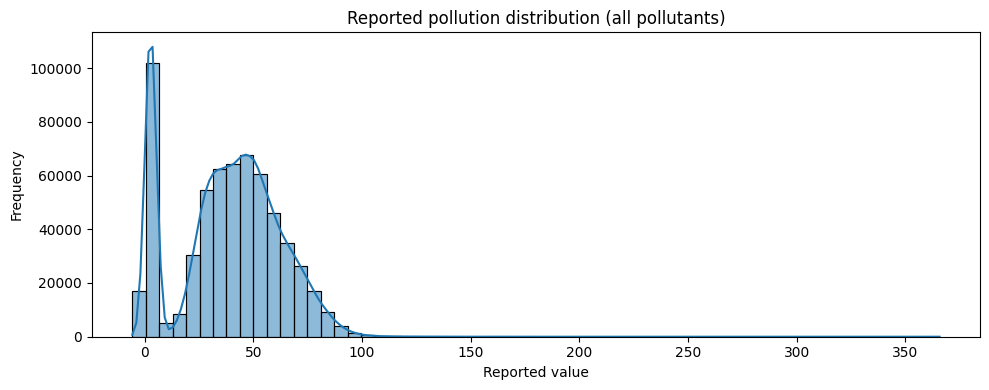

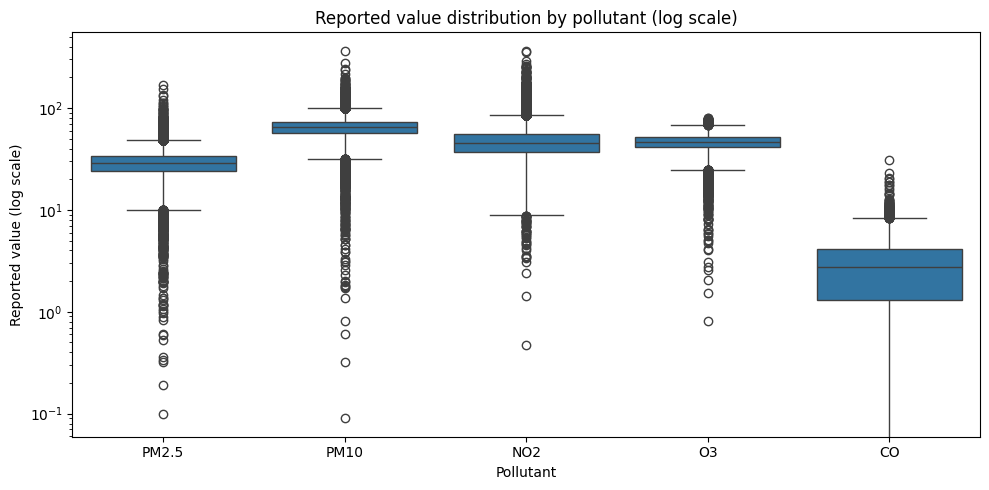

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of reported values across all pollutants
plt.figure(figsize=(10, 4))
sns.histplot(df_model["reported_value"], bins=60, kde=True)
plt.title("Reported pollution distribution (all pollutants)")
plt.xlabel("Reported value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Per-pollutant boxplot (log scale handles cross-pollutant magnitude differences)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x="name", y="reported_value")
plt.yscale("log")
plt.title("Reported value distribution by pollutant (log scale)")
plt.xlabel("Pollutant")
plt.ylabel("Reported value (log scale)")
plt.tight_layout()
plt.show()

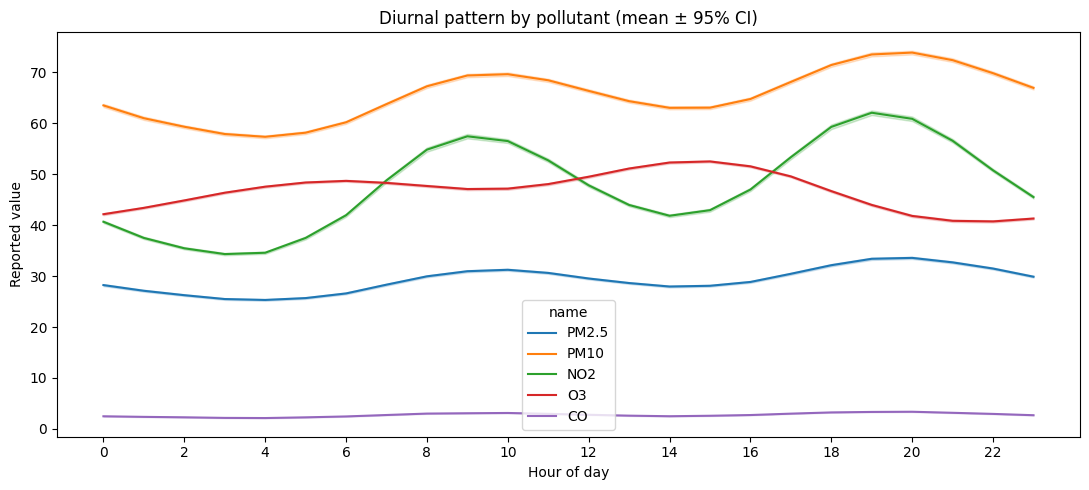

In [ ]:
if "hour" not in df_model.columns:
    print("Skipping diurnal plot — 'hour' column not found.")
else:
    plt.figure(figsize=(11, 5))
    sns.lineplot(data=df_model, x="hour", y="reported_value",
                 hue="name", errorbar="ci")
    plt.title("Diurnal pattern by pollutant (mean ± 95% CI)")
    plt.xlabel("Hour of day")
    plt.ylabel("Reported value")
    plt.xticks(range(0, 24, 2))
    plt.tight_layout()
    plt.show()

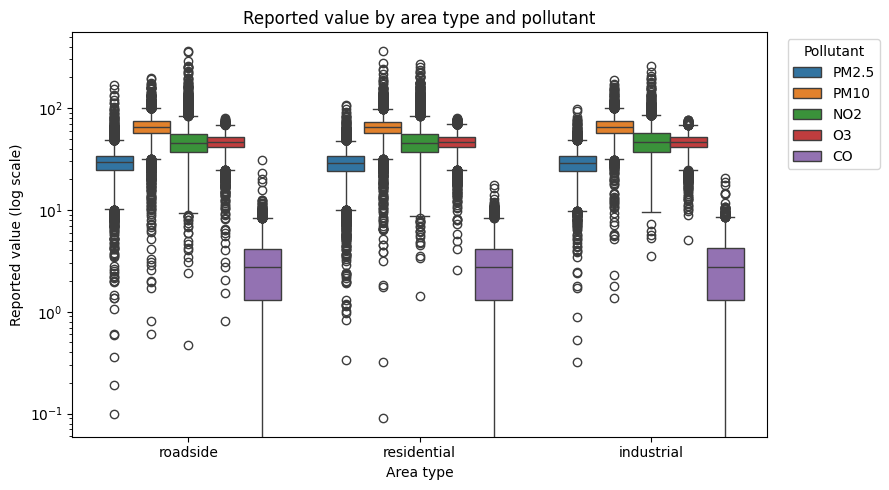

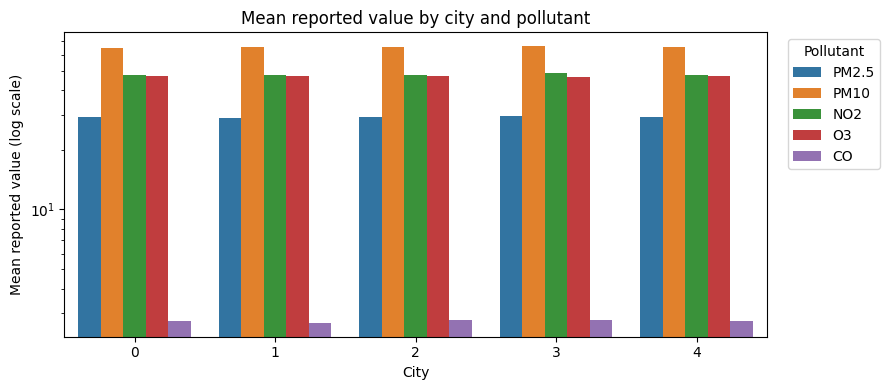

In [ ]:
# By area type — skip if area_type column not present
if "area_type" in df_model.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df_model, x="area_type", y="reported_value", hue="name")
    plt.yscale("log")
    plt.title("Reported value by area type and pollutant")
    plt.xlabel("Area type")
    plt.ylabel("Reported value (log scale)")
    plt.legend(title="Pollutant", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping by-area plot — 'area_type' column not provided.")

# By city — skip if only one city in data
n_cities = df_model["city_id"].nunique()
if n_cities > 1:
    plt.figure(figsize=(9, 4))
    sns.barplot(data=df_model, x="city_id", y="reported_value",
                hue="name", errorbar=None)
    plt.yscale("log")
    plt.title("Mean reported value by city and pollutant")
    plt.xlabel("City")
    plt.ylabel("Mean reported value (log scale)")
    plt.legend(title="Pollutant", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print(f"Skipping by-city plot — only {n_cities} city in data.")

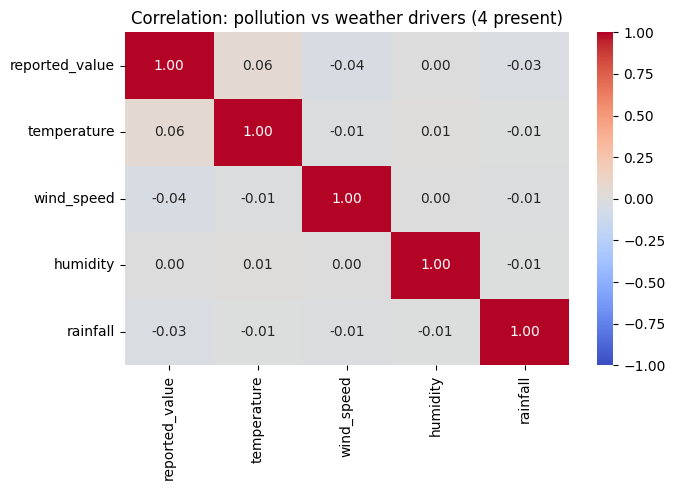

In [ ]:
weather_candidates = ["temperature", "wind_speed", "humidity", "rainfall"]
weather_present = [c for c in weather_candidates if c in df_model.columns]

if weather_present:
    corr_cols = ["reported_value"] + weather_present
    plt.figure(figsize=(7, 5))
    sns.heatmap(df_model[corr_cols].corr(),
                annot=True, cmap="coolwarm", fmt=".2f",
                vmin=-1, vmax=1, center=0)
    plt.title(f"Correlation: pollution vs weather drivers ({len(weather_present)} present)")
    plt.tight_layout()
    plt.show()

    if len(weather_present) < len(weather_candidates):
        absent = set(weather_candidates) - set(weather_present)
        print(f"Note — weather columns missing: {sorted(absent)}")
else:
    print("Skipping weather correlation — no weather columns provided.")

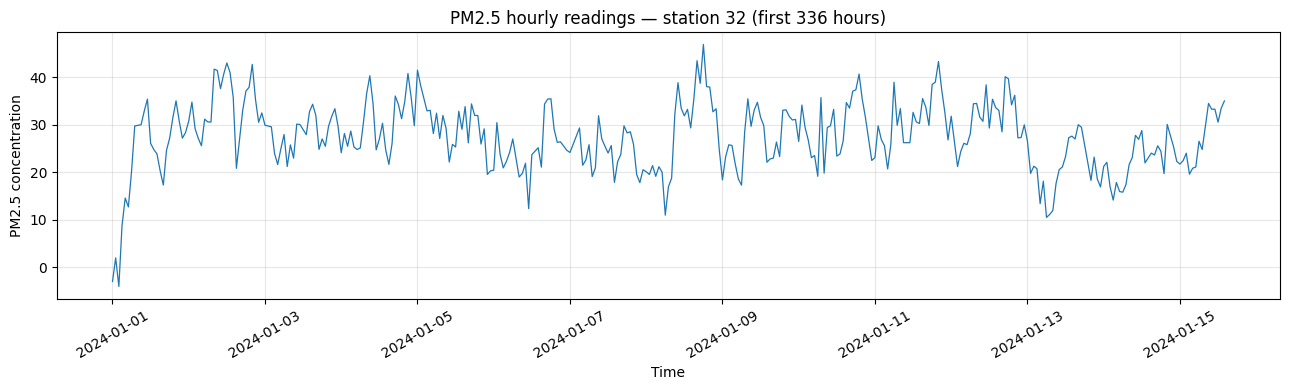

In [ ]:
# Pick a representative station and pollutant
sample_station = df_model["station_id"].mode().iloc[0]

if "PM2.5" in df_model["name"].unique():
    sample_pollutant = "PM2.5"
else:
    sample_pollutant = sorted(df_model["name"].unique())[0]

# Take the first 14 days of data for that (station, pollutant) combo
sub = (df_model[
        (df_model["station_id"] == sample_station)
      & (df_model["name"] == sample_pollutant)
      ]
      .sort_values("datetime")
      .head(24 * 14))

if len(sub) > 0:
    plt.figure(figsize=(13, 4))
    plt.plot(sub["datetime"], sub["reported_value"], linewidth=0.9)
    plt.title(f"{sample_pollutant} hourly readings — station {sample_station} "
              f"(first {len(sub)} hours)")
    plt.ylabel(f"{sample_pollutant} concentration")
    plt.xlabel("Time")
    plt.xticks(rotation=30)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"No data for station {sample_station}, pollutant {sample_pollutant}")

**MODELING**

Using 21 features:
  Numeric:  ['temperature', 'wind_speed', 'humidity', 'rainfall', 'hour', 'dayofweek', 'is_weekend', 'maintenance_score']
  One-hot:  13 columns (area: 3, pol: 5, city: 5)

Train: 491,051 rows (2024-01-01 → 2024-03-13)
Test : 122,524 rows (2024-03-13 → 2024-03-30)

Linear baseline MAE :   6.843   R²: 0.835
Random Forest  MAE :   5.100   R²: 0.902
RF improvement     : +25.5%


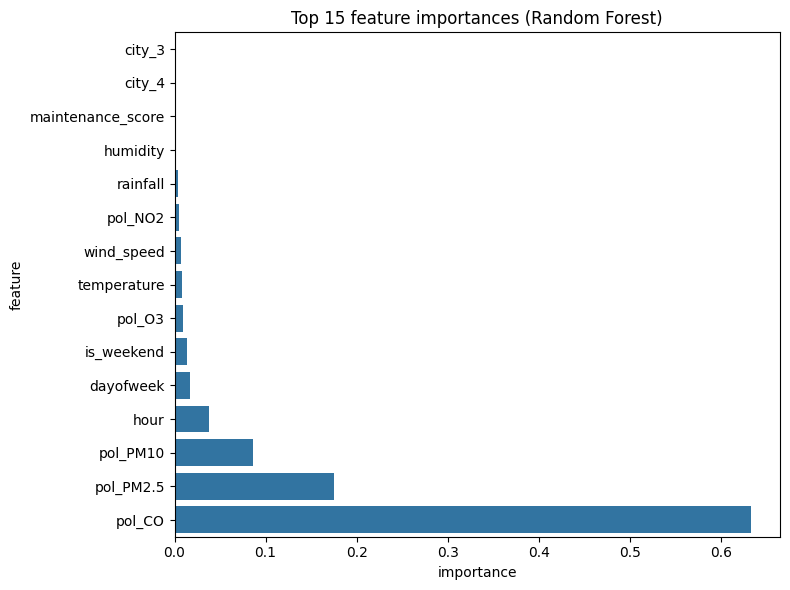

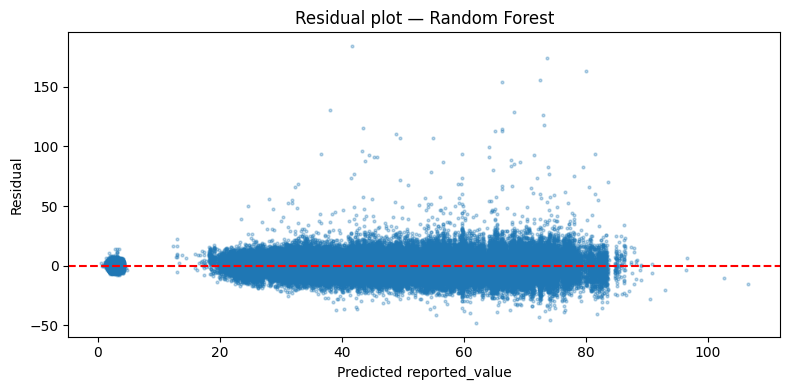

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Build feature matrix with one-hot encodings for categoricals that exist
categorical_cols = [c for c in ["area_type", "name", "city_id"]
                    if c in df_model.columns]
df_feat = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    prefix=["area" if c == "area_type" else
            "pol"  if c == "name" else
            "city" for c in categorical_cols],
    drop_first=False,
)

# Numeric features — only include if column exists
numeric_candidates = ["temperature", "wind_speed", "humidity", "rainfall",
                      "hour", "dayofweek", "is_weekend", "maintenance_score"]
numeric_features = [c for c in numeric_candidates if c in df_feat.columns]

# One-hot prefixes — pulled from whatever pd.get_dummies actually produced
onehot_features = (
    [c for c in df_feat.columns if c.startswith("area_")]
  + [c for c in df_feat.columns if c.startswith("pol_")]
  + [c for c in df_feat.columns if c.startswith("city_")]
)

feature_cols = numeric_features + onehot_features

if not feature_cols:
    print("⚠ No usable features available — regression skipped.")
elif len(df_feat) < 100:
    print(f"⚠ Only {len(df_feat)} rows after preprocessing — regression skipped "
          f"(need at least 100).")
else:
    print(f"Using {len(feature_cols)} features:")
    print(f"  Numeric:  {numeric_features}")
    print(f"  One-hot:  {len(onehot_features)} columns "
          f"(area: {sum(c.startswith('area_') for c in onehot_features)}, "
          f"pol: {sum(c.startswith('pol_') for c in onehot_features)}, "
          f"city: {sum(c.startswith('city_') for c in onehot_features)})")
    print()

    # Chronological 80/20 split — preserves time ordering, avoids leakage
    df_feat = df_feat.sort_values("datetime").reset_index(drop=True)
    cutoff = df_feat["datetime"].quantile(0.8)
    train  = df_feat[df_feat["datetime"] <= cutoff]
    test   = df_feat[df_feat["datetime"]  > cutoff]

    X_train, y_train = train[feature_cols], train["reported_value"]
    X_test,  y_test  = test[feature_cols],  test["reported_value"]

    print(f"Train: {len(X_train):,} rows ({df_feat['datetime'].min().date()} → "
          f"{cutoff.date()})")
    print(f"Test : {len(X_test):,} rows ({cutoff.date()} → "
          f"{df_feat['datetime'].max().date()})")
    print()

    # Linear baseline
    baseline = LinearRegression()
    baseline.fit(X_train, y_train)
    base_pred = baseline.predict(X_test)
    base_mae = mean_absolute_error(y_test, base_pred)
    base_r2  = r2_score(y_test, base_pred)

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=200, max_depth=12,
        n_jobs=-1, random_state=42,
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_r2  = r2_score(y_test, rf_pred)

    print(f"Linear baseline MAE : {base_mae:7.3f}   R²: {base_r2:.3f}")
    print(f"Random Forest  MAE : {rf_mae:7.3f}   R²: {rf_r2:.3f}")
    print(f"RF improvement     : {1 - rf_mae/base_mae:+.1%}")

    # Top feature importance
    imp = (pd.DataFrame({"feature": feature_cols,
                         "importance": rf.feature_importances_})
             .sort_values("importance", ascending=True)
             .tail(15))
    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp, x="importance", y="feature")
    plt.title("Top 15 feature importances (Random Forest)")
    plt.tight_layout()
    plt.show()

    # Residual plot
    residuals = y_test.values - rf_pred
    plt.figure(figsize=(8, 4))
    plt.scatter(rf_pred, residuals, s=4, alpha=0.3)
    plt.axhline(0, ls="--", color="red")
    plt.xlabel("Predicted reported_value")
    plt.ylabel("Residual")
    plt.title("Residual plot — Random Forest")
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Compute AQI per row using the row's pollutant name
df_feat["aqi"] = np.nan
for pol in df_model["name"].dropna().unique():
    if pol not in AQI_BREAKPOINTS:
        continue   # skip pollutants we don't have breakpoints for
    # Match by reading_id for synthetic, by index for client
    if "reading_id" in df_feat.columns and "reading_id" in df_model.columns:
        ids = df_model.loc[df_model["name"] == pol, "reading_id"]
        mask = df_feat["reading_id"].isin(ids)
    else:
        # Client mode: use the pol_<name> one-hot we created in cell 23
        col = f"pol_{pol}"
        mask = df_feat[col] == 1 if col in df_feat.columns else pd.Series(False, index=df_feat.index)
    df_feat.loc[mask, "aqi"] = compute_aqi_vectorized(
        df_feat.loc[mask, "reported_value"].values, pol
    )

# Binary target: AQI > 100 (Unhealthy for Sensitive Groups or worse)
df_feat["high_aqi"] = (df_feat["aqi"] > 100).astype(int)

# Re-create chronological split with the new target
df_feat = df_feat.sort_values("datetime").reset_index(drop=True)
cutoff  = df_feat["datetime"].quantile(0.8)
train   = df_feat[df_feat["datetime"] <= cutoff]
test    = df_feat[df_feat["datetime"]  > cutoff]

X_train, X_test = train[feature_cols], test[feature_cols]
y_train, y_test = train["high_aqi"],   test["high_aqi"]

n_pos_train = int(y_train.sum())
n_pos_test  = int(y_test.sum())
print(f"Train positives: {n_pos_train:,} / {len(y_train):,}  ({y_train.mean():.2%})")
print(f"Test  positives: {n_pos_test:,} / {len(y_test):,}  ({y_test.mean():.2%})")

if n_pos_train < 10 or n_pos_test < 10:
    print()
    print("⚠ Fewer than 10 positive cases in train or test set — classifier skipped.")
    print("  This dataset doesn't have enough AQI > 100 events to train a meaningful model.")
    print("  Possible reasons:")
    print("    • Pollution levels are uniformly below the AQI 100 threshold (clean air).")
    print("    • The pollutants in your data don't have AQI breakpoints defined.")
    print("    • Your data is too short — try a longer time window.")
elif y_train.nunique() < 2 or y_test.nunique() < 2:
    print()
    print("⚠ Target has only one class in train or test — classifier skipped.")
else:
    clf = RandomForestClassifier(
        n_estimators=300, max_depth=14,
        class_weight="balanced",
        n_jobs=-1, random_state=42,
    )
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    print()
    print(classification_report(y_test, pred, digits=3,
                                target_names=["Below AQI 100", "AQI > 100"]))
    print("Confusion matrix:")
    print(pd.DataFrame(
        confusion_matrix(y_test, pred),
        index=["Actual: Below 100", "Actual: AQI > 100"],
        columns=["Pred: Below 100", "Pred: AQI > 100"],
    ))

    # Note for reader
    print()
    print("Note: class_weight='balanced' produces high recall (catches most")
    print("alerts) at the cost of lower precision (more false alarms). Appropriate")
    print("for safety-critical air quality monitoring.")

Train positives: 18,693 / 491,051  (3.81%)
Test  positives: 5,089 / 122,524  (4.15%)

               precision    recall  f1-score   support

Below AQI 100      0.997     0.898     0.945    117435
    AQI > 100      0.283     0.929     0.434      5089

     accuracy                          0.899    122524
    macro avg      0.640     0.914     0.689    122524
 weighted avg      0.967     0.899     0.923    122524

Confusion matrix:
                   Pred: Below 100  Pred: AQI > 100
Actual: Below 100           105442            11993
Actual: AQI > 100              360             4729

Note: class_weight='balanced' produces high recall (catches most
alerts) at the cost of lower precision (more false alarms). Appropriate
for safety-critical air quality monitoring.
